In [1]:
#Brownovo gibanje u 2D
#imamo 5ooo šetaća, nasumično se gibaju, zatvoreni su u kutiji i odbijaju se od zidova-difuzija
#pitanje je u kojoj ćeliji su te č čije smo gibanje stimulirali

In [2]:
#pocetni polozaji x je [40, 60] i y je [15,25]
#hod je ogranicen unutar 0<x<100 i 0<y<100

In [ ]:
#kretanje čestica:
#dx = random između [-0.5, 0.5] dy = random između [-1.5, 1.5]

#uzmi sve elemente niza x koji zadovoljavaju uvjet x < 0

In [25]:
#č se giba slobodno po kontinuiranom prostoru 100x100
import numpy as np

Nw = 5000   # broj čestica
Nk = 5000   # broj koraka

x = np.random.uniform(40, 60, Nw)
y = np.random.uniform(15, 25, Nw)

#  3 trenutka
snapshots = []
times = [0, Nk//2, Nk-1]


for k in range(Nk):

    dx = np.random.uniform(-0.5, 0.5, Nw)
    dy = np.random.uniform(-1.5, 1.5, Nw)

    #x_new = x_old + dx
    x += dx
    y += dy

    # rubni uvjeti: ako udre u zid
    #(ispod donje granice) mijenja predznak
    #(iznad gornje granice) elasticno se odbije
    x[x < 0] = -x[x < 0]
    x[x > 100] = 200 - x[x > 100]

    y[y < 0] = -y[y < 0]
    y[y > 100] = 200 - y[y > 100]
    
    if k in times:
        snapshots.append((x.copy(), y.copy()))

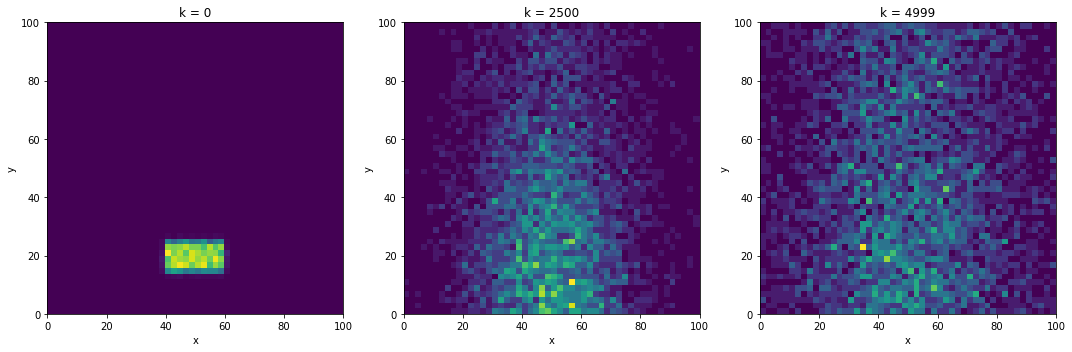

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, (xs, ys) in enumerate(snapshots):
    im = axes[i].hist2d(xs, ys, bins=50, range=[[0,100],[0,100]])
    axes[i].set_title(f"k = {times[i]}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("y")

plt.tight_layout()
plt.show()

In [24]:
# c) distribucija P- napravmo grid i brojimo č u svakoj ćeliji - to je vjerojatnost P

dx = dy = 2
nx = int(100/dx)
ny = int(100/dy)

P = np.zeros((nx, ny))

# indeks ćelije
ix = (x/dx).astype(int)
iy = (y/dy).astype(int)

for i in range(Nw):
    P[ix[i], iy[i]] += 1

# normalizacija
P = P / Nw
rho = P / (dx*dy)

In [7]:
#d)
#proširavamo da racuna S, koliko je ureden sustav
#S=-k suma P_ij ln(P_ij)

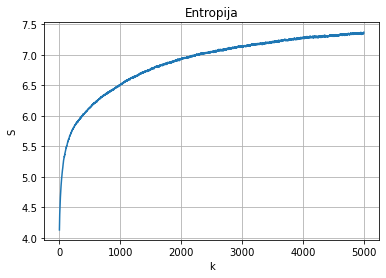

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# parametri (manji za test!)
Nw = 5000
Nk = 5000

dx_cell = 2
dy_cell = 2
nx = int(100/dx_cell)
ny = int(100/dy_cell)

# početno stanje
x = np.random.uniform(40, 60, Nw)
y = np.random.uniform(15, 25, Nw)

S_list = []

for k in range(Nk):

    # random walk (vektorski, OK je)
    dx = np.random.uniform(-0.5, 0.5, Nw)
    dy = np.random.uniform(-1.5, 1.5, Nw)

    x += dx
    y += dy

    # rubovi
    x[x < 0] = -x[x < 0]
    x[x > 100] = 200 - x[x > 100]
    y[y < 0] = -y[y < 0]
    y[y > 100] = 200 - y[y > 100]

    # distribucija
    P = np.zeros((nx, ny))

    ix = (x / dx_cell).astype(int)
    iy = (y / dy_cell).astype(int)

    for i in range(Nw):
        P[ix[i], iy[i]] += 1

    P = P / Nw

    # entropija
    S = -np.sum(P[P > 0] * np.log(P[P > 0]))
    S_list.append(S)

# plot
plt.plot(S_list)
plt.xlabel("k")
plt.ylabel("S")
plt.title("Entropija")
plt.grid()
plt.show()

In [9]:
print(np.sum(P))

1.0


In [10]:
#e)
#izracun <r^2>, pokazati =4Dt, D?

k = 0
k = 500
k = 1000
k = 1500
k = 2000
k = 2500
k = 3000
k = 3500
k = 4000
k = 4500


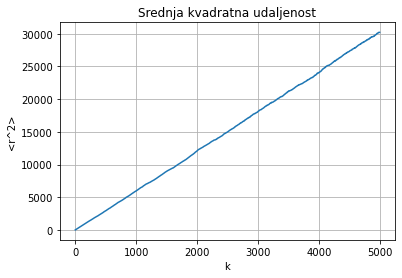

In [27]:
r2_list = []


Nw = 5000
Nk = 5000

# početno stanje
x = np.zeros(Nw)
y = np.zeros(Nw)


x0 = x.copy()
y0 = y.copy()

for k in range(Nk):

    # random walk 
    dx = np.random.uniform(-3, 3, Nw)
    dy = np.random.uniform(-3, 3, Nw)

    x += dx
    y += dy

    # rubovi
   

    # distribucija
    P = np.zeros((500, 500))

    ix = (x / dx_cell).astype(int)
    iy = (y / dy_cell).astype(int)

    for i in range(Nw):
        P[ix[i], iy[i]] += 1

    P = P / Nw
    if k % 500 == 0:
        print("k =", k)
    
    #e)
    r2 = (x-x0)**2 + (y-y0)**2
    mean_r2 = np.mean(r2)

    r2_list.append(mean_r2)


plt.plot(r2_list)
plt.xlabel("k")
plt.ylabel("<r^2>")
plt.title("Srednja kvadratna udaljenost")
plt.grid()
plt.show()

In [28]:
import numpy as np

k = np.arange(len(r2_list))

coef = np.polyfit(k, r2_list, 1)
#trazi najbolju fun koja opisuje podatke, vraća koef y=ax+b
#x=k(vrijeme), y=srednja vr r^2
slope = coef[0]

D = slope / 4

print("slope =", slope)
print("D =", D)

slope = 6.073711975391786
D = 1.5184279938479466


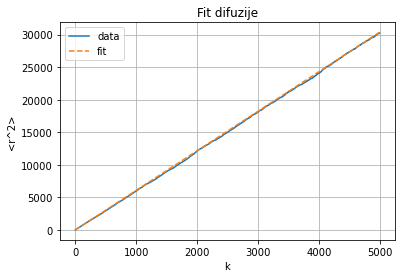

In [29]:
import matplotlib.pyplot as plt

fit_line = slope * k

plt.plot(k, r2_list, label="data")
plt.plot(k, fit_line, '--', label="fit")

plt.xlabel("k")
plt.ylabel("<r^2>")
plt.title("Fit difuzije")
plt.legend()
plt.grid()
plt.show()

In [19]:
import numpy as np

k = np.arange(len(r2_list))

coef = np.polyfit(k, r2_list, 1)
slope = coef[0]

D = slope / 4

print("D =", D)

D = 1.4788848862515216


slope = 5.976725649942174
D_fit = 1.4941814124855435


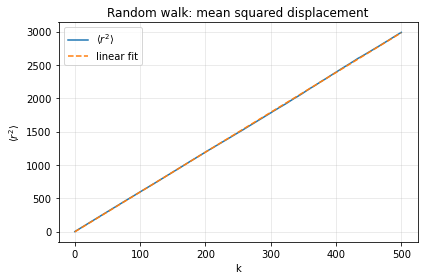

stability parameter = 0.37354535312138587


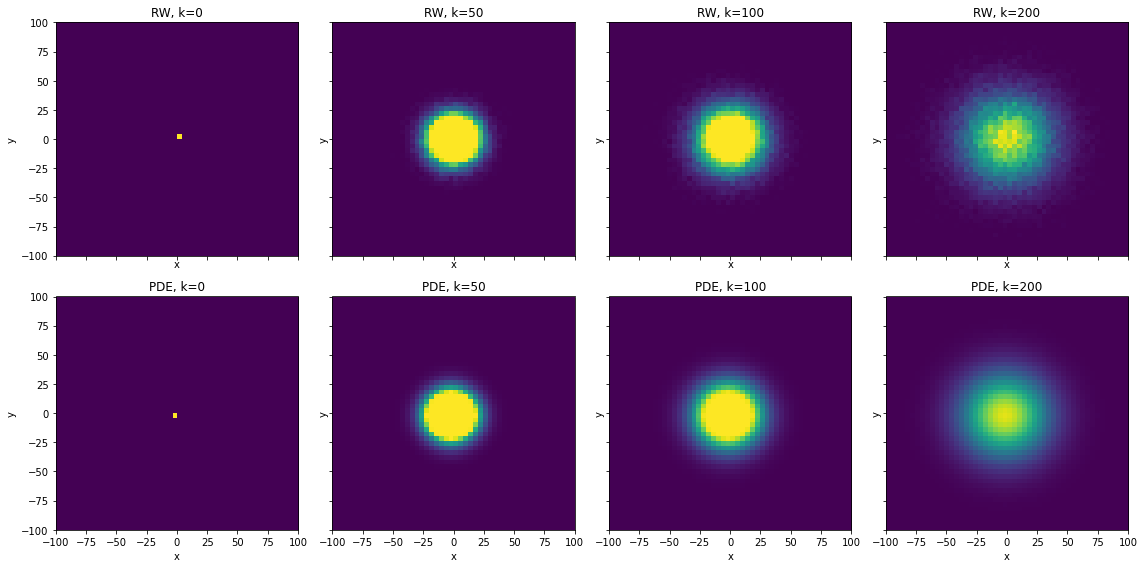

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Nw = 64000
Nk = 500 #korak
step_lim = 3.0          # Δx = Δy in [-3, 3]
snap_steps = [0, 50, 100, 200]

# grid for histograms and PDE
RUB = 100.0
h = 4.0                  # grid spacing for PDE and histograms
edges = np.arange(-RUB, RUB + h, h)
centers = 0.5 * (edges[:-1] + edges[1:])
nx = len(centers)
ny = len(centers)

# walkers start at the origin
x = np.zeros(Nw)
y = np.zeros(Nw)

# store <r^2>(t)
r2_list = []

# store random-walk density snapshots
rw_snaps = {}

#od položaja pravimo P(x,y)
#da vrijednosti ne ovise o veličini ćelije

def density_from_particles(x, y):
    H, _, _ = np.histogram2d(
        x, y,
        bins=[edges, edges],
        range=[[-RUB, RUB], [-RUB, RUB]]
    )
    # broji koliko č padne u svaku ćeliju
    return H / (Nw * h * h)

# initial snapshot
rw_snaps[0] = density_from_particles(x, y)
r2_list.append(np.mean(x*x + y*y))

for k in range(1, Nk + 1):
    dx = np.random.uniform(-step_lim, step_lim, Nw)
    dy = np.random.uniform(-step_lim, step_lim, Nw)

    x += dx
    y += dy

    r2_list.append(np.mean(x*x + y*y))

    if k in snap_steps:
        rw_snaps[k] = density_from_particles(x, y)

# fit <r^2> = 4 D t
k_arr = np.arange(len(r2_list))
coef = np.polyfit(k_arr, r2_list, 1)
slope = coef[0]
D_fit = slope / 4.0

print("slope =", slope)
print("D_fit =", D_fit)

# plot <r^2>(t)
plt.figure(figsize=(6,4))
plt.plot(k_arr, r2_list, label=r"$\langle r^2 \rangle$")
plt.plot(k_arr, np.polyval(coef, k_arr), '--', label="linear fit")
plt.xlabel("k")
plt.ylabel(r"$\langle r^2 \rangle$")
plt.title("Random walk: mean squared displacement")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# e.4 Explicit finite-difference solution of diffusion equation
# rho_t = D (rho_xx + rho_yy)
# boundary condition rho = 0 on the boundary
# ------------------------------------------------------------
# For stability in 2D explicit scheme:
# 4 * D * dt / h^2 <= 1
dt = 1.0
stability = 4.0 * D_fit * dt / (h * h)
print("stability parameter =", stability)   #ako je dt prevelik- parametar>1, preskace susjede

rho = np.zeros((nx, ny))

# trazi indekse ćelija najblizi 0 u svrhu simulacije difuzije gustoće

ix0 = np.argmin(np.abs(centers - 0.0))
iy0 = np.argmin(np.abs(centers - 0.0))
rho[ix0, iy0] = 1.0 / (h * h)

pde_snaps = {0: rho.copy()}

for n in range(1, Nk + 1):
    rho_new = rho.copy()

    rho_new[1:-1, 1:-1] = rho[1:-1, 1:-1] + D_fit * dt * (
        (rho[2:, 1:-1] - 2.0*rho[1:-1, 1:-1] + rho[:-2, 1:-1]) / (h*h) +
        (rho[1:-1, 2:] - 2.0*rho[1:-1, 1:-1] + rho[1:-1, :-2]) / (h*h)
    )

    # boundary rho = 0
    rho_new[0, :] = 0.0
    rho_new[-1, :] = 0.0
    rho_new[:, 0] = 0.0
    rho_new[:, -1] = 0.0

    rho = rho_new

    if n in snap_steps:
        pde_snaps[n] = rho.copy()

# ------------------------------------------------------------
# e.3 / e.5 plots: random walk vs PDE at selected times
# ------------------------------------------------------------
#vmax = 0.0
#for t in snap_steps:
#    vmax = max(vmax, rw_snaps[t].max(), pde_snaps[t].max())

vmax = rw_snaps[t].max()    
  
    
fig, axes = plt.subplots(2, len(snap_steps), figsize=(4*len(snap_steps), 8), sharex=True, sharey=True)

for j, t in enumerate(snap_steps):
    im1 = axes[0, j].imshow(
        rw_snaps[t].T,
        origin='lower',
        extent=[-RUB, RUB, -RUB, RUB],
        vmin=0, vmax=vmax,
        aspect='auto'
    )
    axes[0, j].set_title(f"RW, k={t}")
    axes[0, j].set_xlabel("x")
    axes[0, j].set_ylabel("y")

    im2 = axes[1, j].imshow(
        pde_snaps[t].T,
        origin='lower',
        extent=[-RUB, RUB, -RUB, RUB],
        vmin=0, vmax=vmax,
        aspect='auto'
    )
    axes[1, j].set_title(f"PDE, k={t}")
    axes[1, j].set_xlabel("x")
    axes[1, j].set_ylabel("y")

plt.tight_layout()
plt.show()